# Project 2

This project focuses on analyzing laptop product data from eBay to explore laptop's pricing patterns and hardware distributions on ebay (see figure 1.) 

The data was collected through web scraping: I first browsed through eBay’s search results pages, gathering each product’s title, price, and link from the first 2 pages, or 120 products in total (see figure 2.) Then for each prodoct, I visited its detail page to collect specifications such as Condition, Processor, SSD Capacity, GPU, Release Year, RAM Size, and Model (for example, see figure 3).

figure 1:
<img src="capture1.png" width="400">
figure 2:
<img src="capture2.png" width="400">


figure 3:
<img src="capture3.png" width="400">

# Key Findings

1. Prices are low and right-skewed: Most prices fall roughly between $50–$300, with some expensive laptops.
2. Condition strongly tracks price: New > Very Good > Good > Used.
3. Better Hardware means higher price: Newer models sell for more(except latest models), and 2018–2021 models dominate the market. Also, more RAM/SSD means higher prices
4. The 3 Biggest Brands - Dell, HP, Lenovo- dominate the market.

# Codes for web scraping: 

Compared to Project 1, I added codes for visiting detail page to collect information of each product, so I included the revised codes below.

Import packages

In [27]:
#------------------- IMPORT PACKAGES FOR DATA PROCESSING ----------------------#

# Manage datasets
import pandas as pd
import numpy as np
# Work with time data
import time 

# Conduct HTTP requests
import requests

# Construct tree structure of HTML data
import html5lib

# Parse HTML data obtained from scraping
from bs4 import BeautifulSoup

# Import webdriver for chrome
from webdriver_manager.chrome import ChromeDriverManager


from selenium import webdriver
from webdriver_manager.chrome import ChromeDriverManager


# Automate navigating within browser (SELENIUM)
#------ Key: Manage keys
#------ Select: Obtain features from website
#------ WebDriverWait: Add wait times implicitly
#------ By: Use common information locator strategies
#------ EC and Options: Browser configuration
#------ remote.command: Check whether browser is active

from selenium import webdriver #to automate the navigating within the browser
from selenium.webdriver.chrome.service import service
from selenium.webdriver.common.keys    import Keys
from selenium.webdriver.support.ui     import Select
from selenium.webdriver.support.ui     import WebDriverWait 
from selenium.webdriver.common.by      import By
from selenium.webdriver.support        import expected_conditions as EC
from selenium.webdriver.chrome.options import Options #to use properties of the chrome webbrowser
from selenium.webdriver.remote.command import Command # Use to check whether the web driver is active

import matplotlib.pyplot as plt

In [3]:
opts = Options()                 
driver = webdriver.Chrome(options=opts)
query = "laptop" 
url = f"https://www.ebay.com/sch/i.html?_nkw={query}" # define the url
driver.get(url)
print(driver.current_url)
print(driver.title)
open("debug_ebay.html","w",encoding="utf-8").write(driver.page_source)  # open the ebay page searching for laptops

https://www.ebay.com/sch/i.html?_nkw=laptop
Laptop for sale | eBay


2268489

# Revised Codes to extract detailed information of each product

In [4]:
wait = WebDriverWait(driver, 10)

# Get “Item specifics”
def get_spec(label):
    try:
        xp = f'//dt[.//span[normalize-space()="{label}"]]/following-sibling::dd[1]'
        el = WebDriverWait(driver, 5).until(EC.presence_of_element_located((By.XPATH, xp)))
        return el.text.strip()
    except:
        return None

rows = []
pages_to_get = 2        # 2 pages

for page in range(pages_to_get):
    # 1) wait cards to shown
    wait.until(EC.visibility_of_element_located(
        (By.CSS_SELECTOR, "#srp-river-results li.s-item, #srp-river-results li.s-card")
    ))
    cards = driver.find_elements(By.CSS_SELECTOR,
        "#srp-river-results li.s-item, #srp-river-results li.s-card") # get all cards on the page
    print(f"Page {page+1}: {len(cards)} cards")

    # 2) get info(title, price, link) from search page
    for it in cards:
        # title and price
        title_el = it.find_elements(By.CSS_SELECTOR, ".s-item__title, .s-card__title")
        price_el = it.find_elements(By.CSS_SELECTOR, ".s-item__price, .s-card__price")
        
        title = title_el[0].text.strip() if title_el else None
        price = price_el[0].text.strip() if price_el else None
        
        if not title or title.lower().startswith("shop on ebay"):
            continue
        # link
        try:
            link = title_el[0].find_element(By.XPATH, "./ancestor::a[1]").get_attribute("href")
        except:
            link = None
        if not link:
            continue

        # open new tab, extract info like condition,processor..., then close tab
        driver.execute_script("window.open(arguments[0], '_blank');", link)
        driver.switch_to.window(driver.window_handles[-1]) # to new tab
        try:
            condition = get_spec("Condition")
            processor = get_spec("Processor")
            ssd       = get_spec("SSD Capacity")
            gpu       = get_spec("GPU")
            releaseyr = get_spec("Release Year")
            size      = get_spec("Screen Size")
            ram       = get_spec("RAM Size")
            model     = get_spec("Model")
            rows.append({
                "title": title, "link": link, "price":price,
                "condition": condition, "processor": processor,
                "ssd": ssd, "gpu": gpu, "release_year": releaseyr,
                "screen_size": size, "ram": ram, "model": model
            })
        finally:
            driver.close()
            driver.switch_to.window(driver.window_handles[0])

    # 3) go to next page
    nxt = driver.find_elements(By.CSS_SELECTOR, "nav.pagination a[type='next']")
    if page < pages_to_get-1:                
        if not nxt: break
        sentinel = cards[0] if cards else None
        nxt[0].click()
        if sentinel:
            WebDriverWait(driver, 20).until(EC.staleness_of(sentinel))

# 4) save
pd.DataFrame(rows).to_csv("ebay_detail_2pages.csv", index=False, encoding="utf-8-sig")


Page 1: 60 cards
Page 2: 60 cards


# Codes for data analysis

import dataset

In [5]:
df = pd.read_csv("ebay_detail_2pages.csv")

In [6]:
df.dtypes

title           object
link            object
price           object
condition       object
processor       object
ssd             object
gpu             object
release_year    object
screen_size     object
ram             object
model           object
dtype: object

# Data Cleaning

In [ ]:
# Table of number of observations
summary = pd.DataFrame({
    'non_null': df.count(),
    'na': df.isna().sum(),
    'total': len(df)
})
print(summary)


               non_null  na  total
title               120   0    120
link                120   0    120
price               120   0    120
condition           114   6    120
processor           111   9    120
ssd                  91  29    120
gpu                  86  34    120
release_year         45  75    120
screen_size         113   7    120
ram                 100  20    120
model               111   9    120
ssd_num              79  41    120
size                102  18    120
ram_num              96  24    120
condition_cat       112   8    120
brand               116   4    120


convert to numeric: price, ssd, screen size, ram,year

In [7]:
df['price'] = df['price'].str.replace('$', '', regex=False)  # delete the $ before number
df['price'] = pd.to_numeric(df['price'], errors='coerce')  
print(df['price'].dtype)

float64


In [10]:
df['price'].describe()

count    120.000000
mean     162.389167
std      109.408758
min        0.990000
25%       84.242500
50%      130.270000
75%      209.900000
max      530.000000
Name: price, dtype: float64

In [11]:
df['ssd_num'] = df['ssd'].str.replace('GB', '', regex=False)  # delete the GB
df['ssd_num'] = pd.to_numeric(df['ssd_num'], errors='coerce')  
print(df['ssd_num'].dtype)

float64


In [13]:
df['ram_num'] = df['ram'].str.replace('GB', '', regex=False)  # delete the GB
df['ram_num'] = pd.to_numeric(df['ram_num'], errors='coerce')  
print(df['ram_num'].dtype)

float64


In [12]:
df['size'] = df['screen_size'].str.replace('in', '', regex=False)  # delete the in
df['size'] = pd.to_numeric(df['size'], errors='coerce')  
print(df['size'].dtype)

float64


In [14]:
df["release_year"] = pd.to_numeric(df["release_year"], errors="coerce")
print(df['release_year'].dtype)

float64


classify variable : condition, title(brand)

In [24]:

# Categorizing condition into "New","Very Good" "Good" "Used" "Other"
sc = df["condition"].str.lower()          
df["condition_cat"] = pd.NA               

df.loc[sc.str.contains("new|unused|open box", na=False), "condition_cat"] = "New"
df.loc[sc.str.contains("very good|excellent", na=False), "condition_cat"] = "Very Good"
df.loc[sc.str.contains("good", na=False) & ~sc.str.contains("very good", na=False), "condition_cat"] = "Good"
df.loc[sc.str.contains(r"\bused\b", na=False) & ~sc.str.contains("unused", na=False), "condition_cat"] = "Used"

print(df["condition_cat"].value_counts(dropna=False))

condition_cat
Used         73
Good         26
New          10
<NA>          8
Very Good     3
Name: count, dtype: int64


In [25]:

st = df["title"].str.lower()
df["brand"] = pd.NA

df.loc[st.str.contains("dell|inspiron|alienware|latitude", na=False), "brand"] = "Dell"
df.loc[st.str.contains(r"\bhp\b|hewlett packard", na=False),                  "brand"] = "HP"
df.loc[st.str.contains("lenovo|thinkpad|ideapad", na=False),                  "brand"] = "Lenovo"
df.loc[st.str.contains("asus|vivobook|zenbook|tuf", na=False),                "brand"] = "Asus"
df.loc[st.str.contains("microsoft|surface", na=False),                        "brand"] = "Microsoft"
df.loc[st.str.contains("samsung|galaxy book", na=False),                      "brand"] = "Samsung"
df.loc[st.str.contains("acer", na=False),                                     "brand"] = "Acer"

print(df["brand"].value_counts(dropna=False))


brand
Dell         55
HP           29
Lenovo       26
<NA>          4
Asus          2
Microsoft     2
Acer          1
Samsung       1
Name: count, dtype: int64


summary statistics

In [41]:
print(df[["release_year","ram_num","ssd_num","size"]].describe().T)

              count         mean         std     min     25%     50%     75%  \
release_year   45.0  2019.866667    2.607681  2012.0  2018.0  2020.0  2021.0   
ram_num        96.0    11.625000    6.612986     4.0     8.0     8.0    16.0   
ssd_num        79.0   237.518987  128.883257    32.0   128.0   256.0   256.0   
size          102.0    14.061765    1.393908    10.1    13.3    14.0    15.6   

                 max  
release_year  2025.0  
ram_num         32.0  
ssd_num        512.0  
size            17.3  


# Visualization

In this part, I explored the pricing pattern of the laptops on ebay, and checked how hardware factors affect the prices.

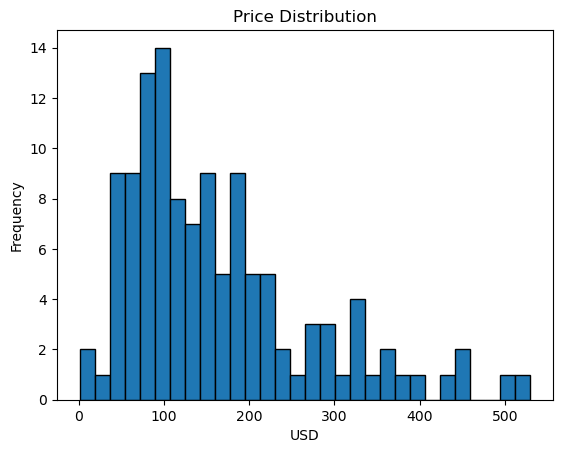

In [ ]:
# Price Distribution
plt.figure()
df["price"].plot(kind="hist", bins=30, edgecolor="black")
plt.title("Price Distribution")
plt.xlabel("USD")
plt.show()


From the distribution above, we can find that prices of most of the laptops are between 50$ and 300$ and much cheaper than normal new laptops, which makes sense as they are from a second-hand electronics market

<Figure size 640x480 with 0 Axes>

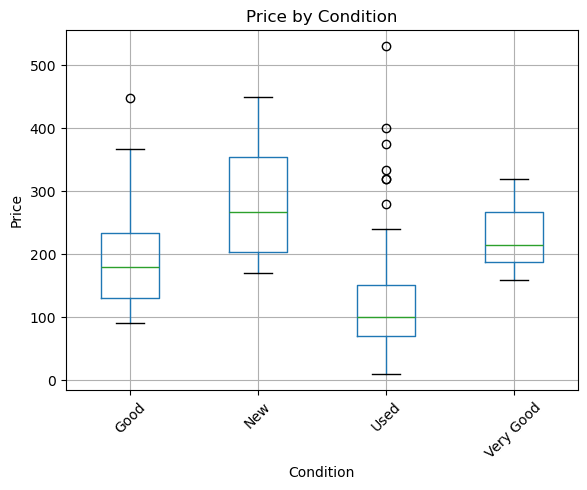

In [ ]:
# Price by Condition
plt.figure()
df.boxplot(column="price", by="condition_cat", rot=45)
plt.title("Price by Condition")
plt.suptitle("")
plt.xlabel("Condition"); plt.ylabel("Price")
plt.show()

From the figure above we know that the mean of prices decreases as condition goes worse, which makes sense as newer laptops have higher prices on average.

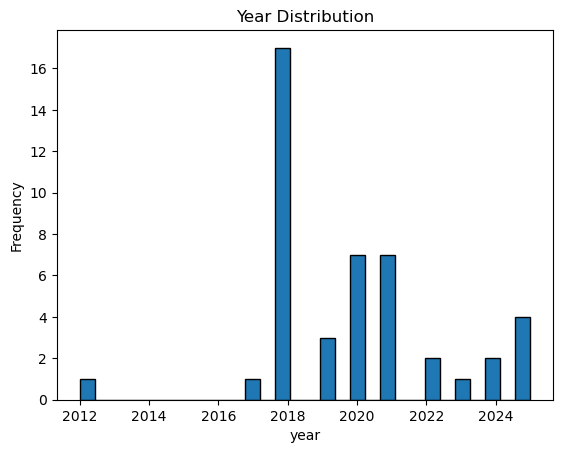

In [38]:
# Year Distribution
plt.figure()
df["release_year"].plot(kind="hist", bins=30, edgecolor="black")
plt.title("Year Distribution")
plt.xlabel("year")
plt.show()

From this figure, we know that the most common used laptops are models released in 2018. Most of the models are released between 2018 to 2021, while there are less newer models(released after 2022) on ebay.

<Figure size 640x480 with 0 Axes>

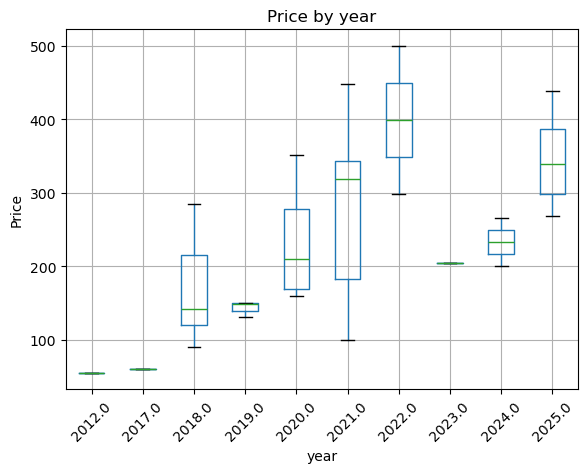

In [37]:
# Price by year
plt.figure()
df.boxplot(column="price", by="release_year", rot=45)
plt.title("Price by year")
plt.suptitle("")
plt.xlabel("year"); plt.ylabel("Price")
plt.show()

From 2018 to 2022, prices increase on average as models go newer. 

However, the average price of newer models(2023, 2024, 2025) is lower than that of 2022 models, there can be several reasons: newer models observations are small, or newer models may belong to the lower-end series (new models from the high-end series haven't become outdated yet and are rarely found on eBay).

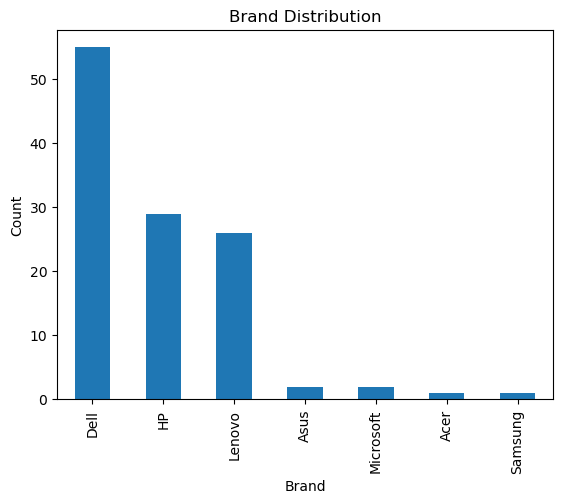

In [33]:
# Brand Distribution
plt.figure()
df["brand"].value_counts().plot(kind="bar")
plt.title("Brand Distribution")
plt.xlabel("Brand")
plt.ylabel("Count")
plt.show()

From this figure we know that Dell, HP, and Lenovo are the 3 most popular brands accounting for the majority of the second hand market on ebay, which makes sense because they are also the 3 biggest brands for the new computer market in the United States.

<Figure size 640x480 with 0 Axes>

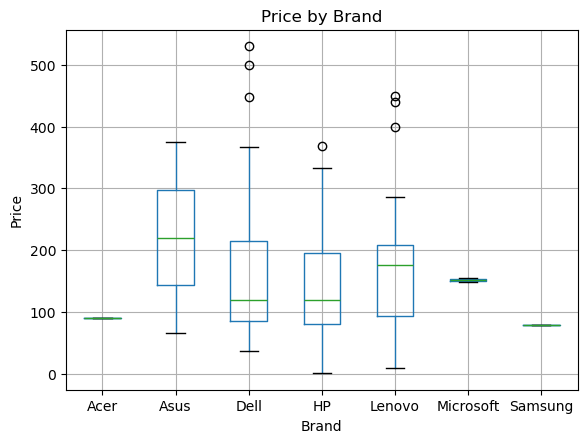

In [31]:
plt.figure()
df.boxplot(column="price", by="brand")
plt.title("Price by Brand")
plt.suptitle("")
plt.xlabel("Brand"); plt.ylabel("Price")
plt.show()

Compared to Dell and HP, Lenovo has higher prices on average. Other brands' observations are too small to provide any meaningful information.

<Figure size 640x480 with 0 Axes>

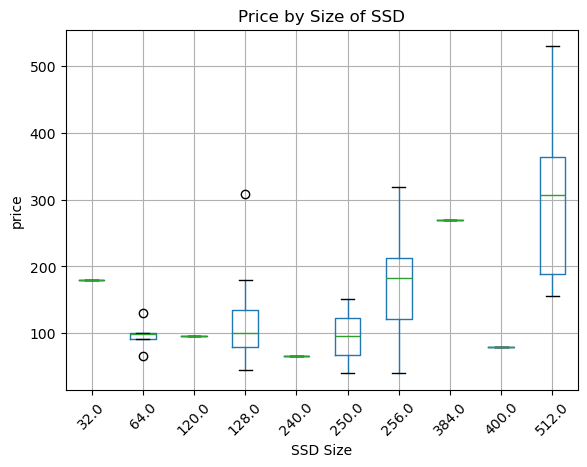

In [35]:
# Price by SSD
plt.figure()
df.boxplot(column="price", by="ssd_num", rot=45)
plt.title("Price by Size of SSD")
plt.suptitle("")
plt.xlabel("SSD Size"); plt.ylabel("price")
plt.show()

Compared to new computers, these second-hand laptops have smaller SSDs, with many under 512GB. From 128gb, 256gb to 512gb, The price increases on average. 

Also, some laptops have SSDs that are not standard in size, like 240gb, 384gb, 400gb, etc.

<Figure size 640x480 with 0 Axes>

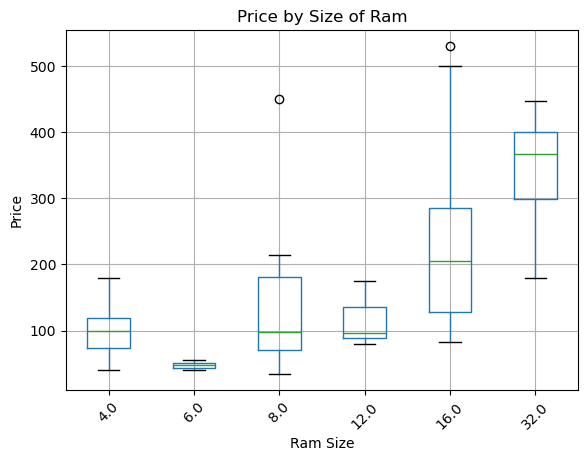

In [36]:
# Price by Ram
plt.figure()
df.boxplot(column="price", by="ram_num", rot=45)
plt.title("Price by Size of Ram")
plt.suptitle("")
plt.xlabel("Ram Size"); plt.ylabel("Price")
plt.show()

Compared to new computers, these second-hand laptops have smaller Rams, with many under 16gb. As ram size increases, The price increases on average. 


<Figure size 640x480 with 0 Axes>

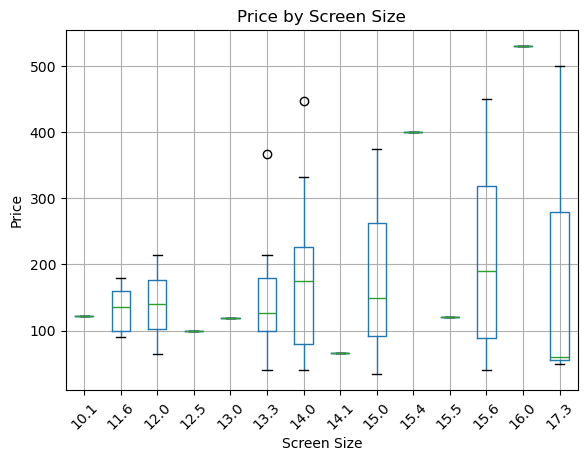

In [40]:
# Price by screen size
plt.figure()
df.boxplot(column="price", by="size", rot=45)
plt.title("Price by Screen Size")
plt.suptitle("")
plt.xlabel("Screen Size"); plt.ylabel("Price")
plt.show()

Price does not correlate significantly with screen size.